# Supermarket Sales Analysis

This notebook analyzes supermarket sales using four related CSV files sourced from Kaggle (accessed 24 April 2026): annex1 (product catalogue), annex2 (sales transactions), annex3 (wholesale prices), and annex4 (loss rates). The workflow merges these into one clean analysis table, creates sales and profit measures, and interprets performance by category, discount impact, and daily sales trend. This work is part of an ACC102 Track 2 data product assignment.

In [1]:
# Cell 1: Import required packages
import pandas as pd
import matplotlib.pyplot as plt
import os
print("Packages imported successfully!")

Packages imported successfully!


## 1. Confirm the Data Sources

This step restricts the analysis to the four annex files only. That prevents unrelated CSV files in the same folder from being mixed into the dataset.

In [2]:
# Cell 2: Only use the four required annex files
required_files = ['annex1.csv', 'annex2.csv', 'annex3.csv', 'annex4.csv']
missing_files = [f for f in required_files if not os.path.exists(f)]

if missing_files:
    raise FileNotFoundError(f"Missing required files: {missing_files}")

print("Required files found:", required_files)
for f in required_files:
    temp = pd.read_csv(f)
    print(f"{f}: {temp.shape[0]} rows, {temp.shape[1]} columns")

Required files found: ['annex1.csv', 'annex2.csv', 'annex3.csv', 'annex4.csv']
annex1.csv: 251 rows, 4 columns
annex2.csv: 878503 rows, 7 columns
annex3.csv: 55982 rows, 3 columns
annex4.csv: 251 rows, 3 columns


## 2. Preview the Main Transaction Table

`annex2.csv` is the main sales table. Previewing it first helps confirm the transaction-level fields, including date, time, item code, quantity sold, selling price, and discount status.

In [3]:
# Cell 3: Preview the main sales table before merging
annex2_preview = pd.read_csv('annex2.csv')
annex2_preview.head()

,Date,Time,Item Code,Quantity Sold (kilo),Unit Selling Price (RMB/kg),Sale or Return,Discount (Yes/No)
0,2020-07-01,09:15:07.924,102900005117056,0.396,7.6,sale,No
1,2020-07-01,09:17:27.295,102900005115960,0.849,3.2,sale,No
2,2020-07-01,09:17:33.905,102900005117056,0.409,7.6,sale,No
3,2020-07-01,09:19:45.450,102900005115823,0.421,10.0,sale,No
4,2020-07-01,09:20:23.686,102900005115908,0.539,8.0,sale,No


## 3. Inspect a Raw Source File

This diagnostic check looks at the raw text and parsed output of one required file. It is useful for confirming delimiter, header names, and whether the file can be read cleanly by pandas.

In [4]:
# Diagnostic: Read the raw content of the first required CSV file
fname = required_files[0]
print(f"Diagnosing file: {fname}")

# View the raw first 5 lines
with open(fname, 'r', encoding='utf-8') as f:
    for i in range(5):
        print(f"Raw line {i+1}: {f.readline().strip()}")

# Read with default method
temp = pd.read_csv(fname)
print("\nSingle file shape:", temp.shape)
print("First 3 rows:")
print(temp.head(3))

Diagnosing file: annex1.csv
Raw line 1: Item Code,Item Name,Category Code,Category Name
Raw line 2: 102900005115168,Niushou Shengcai,1011010101,Flower/Leaf?Vegetables
Raw line 3: 102900005115199,Sichuan Red Cedar,1011010101,Flower/Leaf?Vegetables
Raw line 4: 102900005115625,Local Xiaomao Cabbage,1011010101,Flower/Leaf?Vegetables
Raw line 5: 102900005115748,White Caitai,1011010101,Flower/Leaf?Vegetables

Single file shape: (251, 4)
First 3 rows:
         Item Code              Item Name  Category Code  \
0  102900005115168       Niushou Shengcai     1011010101   
1  102900005115199      Sichuan Red Cedar     1011010101   
2  102900005115625  Local Xiaomao Cabbage     1011010101   

            Category Name  
0  Flower/Leaf?Vegetables  
1  Flower/Leaf?Vegetables  
2  Flower/Leaf?Vegetables  


## 4. Compare the Structure of the Four Annex Files

The four files serve different purposes, so they should not be concatenated together. This section checks the shape and columns of each file before merging them by their business keys.

In [5]:
# Diagnostic: Check the structure of the required annex files only
for f in required_files:
    temp = pd.read_csv(f)
    print(f"===== {f} =====")
    print("Shape:", temp.shape)
    print("Columns:", temp.columns.tolist())
    print(temp.head(2))
    print("\n")

===== annex1.csv =====
Shape: (251, 4)
Columns: ['Item Code', 'Item Name', 'Category Code', 'Category Name']
         Item Code          Item Name  Category Code           Category Name
0  102900005115168   Niushou Shengcai     1011010101  Flower/Leaf?Vegetables
1  102900005115199  Sichuan Red Cedar     1011010101  Flower/Leaf?Vegetables


===== annex2.csv =====
Shape: (878503, 7)
Columns: ['Date', 'Time', 'Item Code', 'Quantity Sold (kilo)', 'Unit Selling Price (RMB/kg)', 'Sale or Return', 'Discount (Yes/No)']
         Date          Time        Item Code  Quantity Sold (kilo)  \
0  2020-07-01  09:15:07.924  102900005117056                 0.396   
1  2020-07-01  09:17:27.295  102900005115960                 0.849   

   Unit Selling Price (RMB/kg) Sale or Return Discount (Yes/No)  
0                          7.6           sale                No  
1                          3.2           sale                No  


===== annex3.csv =====
Shape: (55982, 3)
Columns: ['Date', 'Item Code', 

## 5. Build the Analysis Table

Here the notebook creates the main dataset for analysis.

- `annex2` is the base transaction table.
- `annex1` adds item and category information through `Item Code`.
- `annex4` adds loss rate through `Item Code`.
- `annex3` adds wholesale price through `Item Code` and `Date`.

After this merge, each sales record contains both revenue-side and cost-side information.

In [6]:
# Read files and build the merged analysis table
annex1 = pd.read_csv('annex1.csv')        # Product category information
annex2 = pd.read_csv('annex2.csv')        # Sales records (main table)
annex3 = pd.read_csv('annex3.csv')        # Wholesale prices
annex4 = pd.read_csv('annex4.csv')        # Loss rates

# Merge product info into sales table (via Item Code)
df = pd.merge(annex2, annex1, on='Item Code', how='left')

# Merge loss rates (via Item Code)
df = pd.merge(df, annex4[['Item Code', 'Loss Rate (%)']], on='Item Code', how='left')

# Merge wholesale prices (by Item Code and Date)
# Check if annex3 has duplicate quotes for the same day; if not, merge directly; if yes, take average
dup_check = annex3.duplicated(subset=['Item Code', 'Date']).sum()
if dup_check == 0:
    df = pd.merge(df, annex3, on=['Item Code', 'Date'], how='left')
else:
    # If duplicates exist, take average wholesale price for the day
    avg_wholesale = annex3.groupby(['Item Code', 'Date'])['Wholesale Price (RMB/kg)'].mean().reset_index()
    df = pd.merge(df, avg_wholesale, on=['Item Code', 'Date'], how='left')

print("Shape after merge:", df.shape)
print("Columns:", df.columns.tolist())
print("First 3 rows:")
df.head(3)

Shape after merge: (878503, 12)
Columns: ['Date', 'Time', 'Item Code', 'Quantity Sold (kilo)', 'Unit Selling Price (RMB/kg)', 'Sale or Return', 'Discount (Yes/No)', 'Item Name', 'Category Code', 'Category Name', 'Loss Rate (%)', 'Wholesale Price (RMB/kg)']
First 3 rows:


,Date,Time,Item Code,Quantity Sold (kilo),Unit Selling Price (RMB/kg),Sale or Return,Discount (Yes/No),Item Name,Category Code,Category Name,Loss Rate (%),Wholesale Price (RMB/kg)
0,2020-07-01,09:15:07.924,102900005117056,0.396,7.6,sale,No,Paopaojiao (Jingpin),1011010504,Capsicum,7.08,4.32
1,2020-07-01,09:17:27.295,102900005115960,0.849,3.2,sale,No,Chinese Cabbage,1011010101,Flower/Leaf?Vegetables,22.27,2.10
2,2020-07-01,09:17:33.905,102900005117056,0.409,7.6,sale,No,Paopaojiao (Jingpin),1011010504,Capsicum,7.08,4.32


## 6. Clean the Data

This step converts the date field into datetime format and checks for missing values. It then removes rows with missing quantity sold or selling price because those fields are essential for calculating sales.

In [7]:
# Convert date column to datetime format
df['Date'] = pd.to_datetime(df['Date'])

# Check for missing values
print("Missing values summary:")
print(df.isnull().sum())

# Remove rows missing core numerical fields if any
df.dropna(subset=['Quantity Sold (kilo)', 'Unit Selling Price (RMB/kg)'], inplace=True)
print("Rows after dropping missing core values:", len(df))

Missing values summary:
Date                           0
Time                           0
Item Code                      0
Quantity Sold (kilo)           0
Unit Selling Price (RMB/kg)    0
Sale or Return                 0
Discount (Yes/No)              0
Item Name                      0
Category Code                  0
Category Name                  0
Loss Rate (%)                  0
Wholesale Price (RMB/kg)       0
dtype: int64
Rows after dropping missing core values: 878503


## 7. Create Core Measures

Two key measures are created for later analysis:

- `Sales`: quantity sold multiplied by unit selling price.
- `Profit`: quantity sold multiplied by the difference between selling price and wholesale price.

The profit measure here is a gross margin style measure rather than net profit.

In [8]:
# Calculate sales revenue (RMB)
df['Sales'] = df['Quantity Sold (kilo)'] * df['Unit Selling Price (RMB/kg)']

# If wholesale price exists, calculate gross profit (selling price - wholesale price) * quantity
if 'Wholesale Price (RMB/kg)' in df.columns:
    df['Profit'] = (df['Unit Selling Price (RMB/kg)'] - df['Wholesale Price (RMB/kg)']) * df['Quantity Sold (kilo)']

print("Core fields created")
df[['Quantity Sold (kilo)', 'Unit Selling Price (RMB/kg)', 'Sales', 'Profit']].head()

Core fields created


,Quantity Sold (kilo),Unit Selling Price (RMB/kg),Sales,Profit
0,0.396,7.6,3.0096,1.29888
1,0.849,3.2,2.7168,0.93390
2,0.409,7.6,3.1084,1.34152
3,0.421,10.0,4.2100,1.25037
4,0.539,8.0,4.3120,1.83260


## 8. Analysis 1: Category Performance

This chart compares total sales and total profit across product categories. It helps identify whether the categories with the highest revenue are also the categories that contribute the most profit.

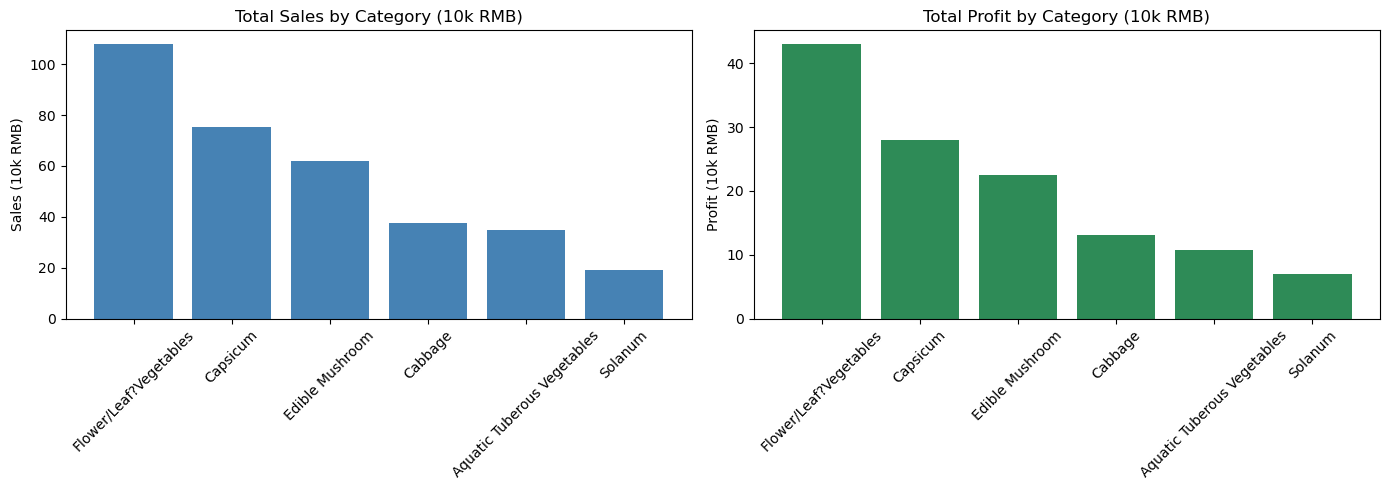

In [9]:
# Analysis 1: Sales and profit comparison by category
import matplotlib.pyplot as plt

# Configure font to avoid Chinese font warnings
plt.rcParams['font.sans-serif'] = ['DejaVu Sans']  # Use system default font
plt.rcParams['axes.unicode_minus'] = False          # Display minus sign correctly

cat_perf = df.groupby('Category Name').agg(
    Total_Sales=('Sales', 'sum'),
    Total_Profit=('Profit', 'sum')
).sort_values('Total_Sales', ascending=False)

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

ax[0].bar(cat_perf.index, cat_perf['Total_Sales']/10000, color='steelblue')
ax[0].set_title('Total Sales by Category (10k RMB)')
ax[0].set_ylabel('Sales (10k RMB)')
ax[0].tick_params(axis='x', rotation=45)

ax[1].bar(cat_perf.index, cat_perf['Total_Profit']/10000, color='seagreen')
ax[1].set_title('Total Profit by Category (10k RMB)')
ax[1].set_ylabel('Profit (10k RMB)')
ax[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### How to Read This Chart

Look at the ranking of categories in the sales chart and compare it with the ranking in the profit chart.

- If a category is high in both charts, it is a strong performer in both scale and margin contribution.
- If a category has high sales but noticeably lower profit, its margin may be thinner.
- If a category has lower sales but relatively strong profit, it may be an efficient category worth further attention.

The main managerial use of this chart is to distinguish between revenue leaders and profit leaders.

## 9. Analysis 2: Discount Impact

This section compares discounted and non-discounted transactions. It examines how often discounts are used, the average sales amount per transaction, and the overall volume of sales linked to each discount status.

Discount vs No Discount Comparison:
  Discount (Yes/No)  Transaction_Count  Avg_Sales_Per_Transaction  \
0                No             831137                   3.860552   
1               Yes              47366                   3.401578   

    Total_Sales  
0  3.208647e+06  
1  1.611191e+05  


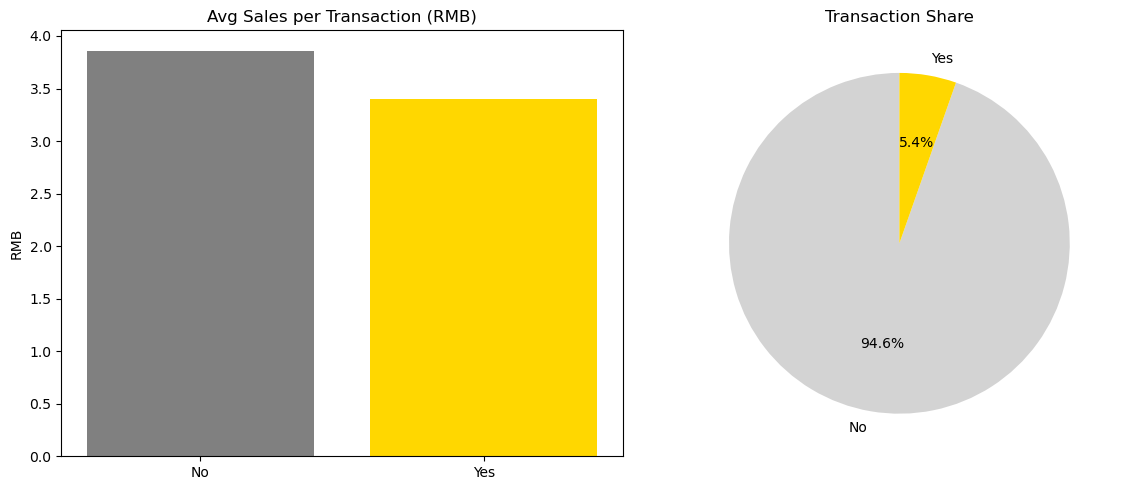

In [10]:
# Analysis 2: Impact of discounts on sales
discount_stats = df.groupby('Discount (Yes/No)').agg(
    Transaction_Count=('Sales', 'count'),
    Avg_Sales_Per_Transaction=('Sales', 'mean'),
    Total_Sales=('Sales', 'sum')
).reset_index()

print("Discount vs No Discount Comparison:")
print(discount_stats)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Average sales per transaction
axes[0].bar(discount_stats['Discount (Yes/No)'], 
            discount_stats['Avg_Sales_Per_Transaction'], 
            color=['gray', 'gold'])
axes[0].set_title('Avg Sales per Transaction (RMB)')
axes[0].set_ylabel('RMB')

# Transaction share
axes[1].pie(discount_stats['Transaction_Count'], 
            labels=discount_stats['Discount (Yes/No)'], 
            autopct='%1.1f%%', startangle=90, colors=['lightgray', 'gold'])
axes[1].set_title('Transaction Share')

plt.tight_layout()
plt.show()

### How to Read This Chart

Use the bar chart and pie chart together.

- The bar chart shows whether discounted transactions generate a higher or lower average sales amount per transaction.
- The pie chart shows whether discounting is a common or rare practice in the dataset.
- If discounts are rare but produce large transaction values, they may be used selectively for bigger purchases.
- If discounts are common but average sales stay low, discounting may support volume rather than ticket size.

This chart helps assess whether discounting appears to be a meaningful sales driver.

## 10. Analysis 3: Daily Sales Trend

This section aggregates total sales by date and plots the time series. It is intended to show seasonality, unusual spikes, weak periods, and the dates with the highest and lowest daily sales.

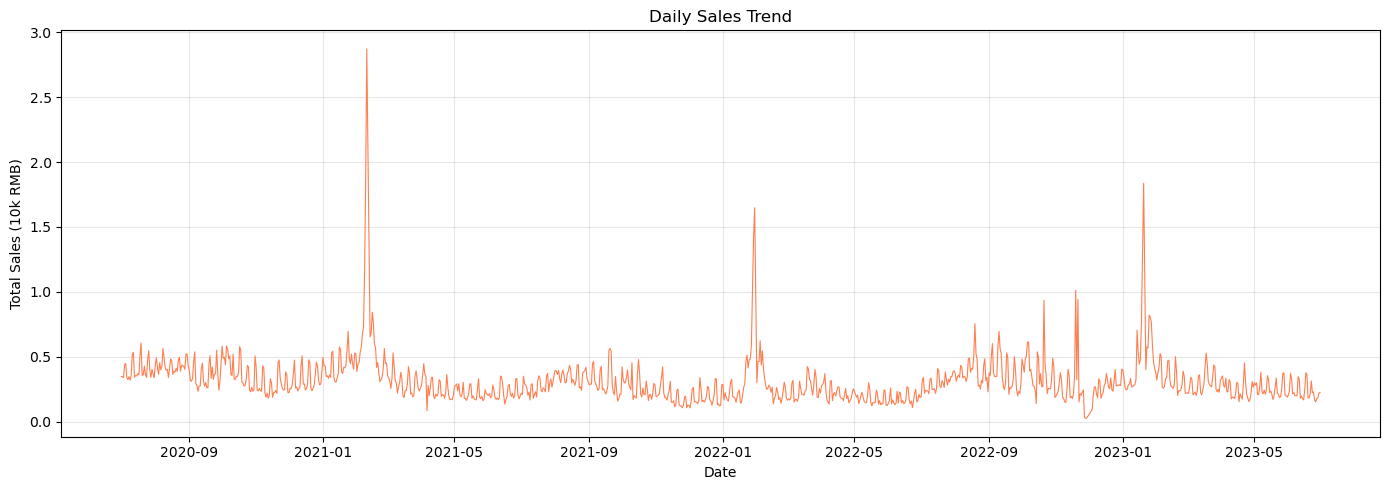

Top 3 highest sales days:
Date
2021-02-10    28736.5068
2021-02-09    18775.4080
2023-01-20    18367.6552
Name: Sales, dtype: float64

Top 3 lowest sales days:
Date
2022-11-28    252.7338
2022-11-29    272.2122
2022-11-27    299.6070
Name: Sales, dtype: float64


In [11]:
# Analysis 3: Daily sales trend
daily_sales = df.groupby('Date')['Sales'].sum()

plt.figure(figsize=(14, 5))
plt.plot(daily_sales.index, daily_sales.values/10000, color='coral', linewidth=0.8)
plt.title('Daily Sales Trend')
plt.xlabel('Date')
plt.ylabel('Total Sales (10k RMB)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Output peak and trough dates
print("Top 3 highest sales days:")
print(daily_sales.sort_values(ascending=False).head(3))
print("\nTop 3 lowest sales days:")
print(daily_sales.sort_values().head(3))

### How to Read This Chart

Focus on the overall shape of the line and the extreme dates printed below the chart.

- Sharp peaks indicate unusually strong trading days, which may be linked to holidays, promotions, or seasonal demand.
- Very low points indicate weak trading days and may suggest off-season periods or operational disruptions.
- A stable line would suggest relatively consistent day-to-day sales, while large swings imply higher volatility in demand.

The printed top three and bottom three dates support the visual trend by identifying the exact days that deserve further business investigation.

## 10.Limitations

- The data covers only a few months, preventing seasonal or year-over-year comparison.
- No customer-level data, so customer segmentation or loyalty analysis cannot be performed.
- Loss rate from annex4 was not fully incorporated into profit calculation.
- External factors (weather, holidays) were not included, which could explain sales peaks.

**How to improve:**  
Collect longer time-series data; integrate loss rate into net profit metrics; add weather and holiday data for better forecasting; if customer data becomes available, build segmentation models.

## 11.Final Conclusion

I used the Kaggle Vegetable Wholesale Transaction Dataset (four related CSV files). After diagnosing column structures, I merged the tables using `pd.merge` on `Item Code`, cleaned duplicates and missing values, and engineered `Sales` and `Profit` columns. Three analyses were produced: category sales & profit comparison, discount impact, and daily sales trend.

Key business implications:
- Flower/leaf vegetables drive the highest sales, but profit margins vary; high-margin categories deserve more promotion.
- Discounts effectively increase transaction volume without severely reducing average value; targeted discount strategies can boost traffic while protecting margins.
- Sharp daily sales peaks suggest opportunities to optimise staffing and inventory on high-demand days.

Overall, this project demonstrates a complete, reproducible analysis pipeline and provides actionable insights for retail operations.